# Laboratorio 1
**Redes Neuronales para Lenguaje Natural, 2026**

Este laboratorio está basado en [TA1C (Te Ahorré Un Click)](https://www.fing.edu.uy/inco/grupos/pln/ta1c/), una competencia organizada en IberLEF 2025 por el grupo PLN del Inco, centrada en la detección y resolución de clickbait en noticias en español. Se considera clickbait a un texto que omite deliberadamente parte de la información con el objetivo de generar curiosidad y motivar al lector a acceder a la noticia.

En particular, trabajaremos sobre la subtarea de detección de clickbait, formulada como un problema de clasificación binaria. A partir del texto de un tweet que contiene el titular de una noticia, el objetivo será determinar si es clickbait o no.

A lo largo del laboratorio construiremos distintos clasificadores basados en redes neuronales para resolver esta tarea, con el objetivo de explorar el uso de word embeddings y comparar distintas arquitecturas de redes neuronales.

**Entrega: 5 de octubre de 2026**

**Formato: notebook de Python (.ipynb)**

**No olvidar mantener todas las salidas de cada región de código en el notebook!**

---



## 0. Preparación del entorno

Comenzamos con algunos imports y definiciones.

In [1]:
! pip install --upgrade gensim
! pip install --upgrade torch
import re
import unicodedata
import gensim.downloader as api
import nltk
from nltk.corpus import stopwords
# Descarga el recurso de stop words (si no existe, lo baja una sola vez).
nltk.download("stopwords", quiet=True)

import torch
import gensim
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix

CLICKBAIT_LABELS = ['No','Clickbait']
CLICKBAIT_ID = {p:i for (i,p) in enumerate(CLICKBAIT_LABELS) }

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59

Descargamos el dataset de titulares de noticias, que incluye la anotación binaria en clickbait o no. Por más información sobre el dataset, consulte [aquí](https://github.com/pln-fing-udelar/pln-inco-resources/tree/master/clickbait/iberlef2025/detection).

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

# Lista de archivos del dataset a descargar
urls = [
    "https://raw.githubusercontent.com/pln-fing-udelar/pln-inco-resources/master/clickbait/iberlef2025/detection/TA1C_dataset_detection_train.csv",
    "https://raw.githubusercontent.com/pln-fing-udelar/pln-inco-resources/master/clickbait/iberlef2025/detection/TA1C_dataset_detection_dev_gold.csv",
    "https://raw.githubusercontent.com/pln-fing-udelar/pln-inco-resources/master/clickbait/iberlef2025/detection/TA1C_dataset_detection_test_gold.csv",
]

# Descarga cada archivo y lo guarda con su nombre original
for url in urls:
    filename = Path(url).name
    print(f"Descargando {filename}...")
    urlretrieve(url, filename)
    print(f"OK: {filename}")

Descargando TA1C_dataset_detection_train.csv...
OK: TA1C_dataset_detection_train.csv
Descargando TA1C_dataset_detection_dev_gold.csv...
OK: TA1C_dataset_detection_dev_gold.csv
Descargando TA1C_dataset_detection_test_gold.csv...
OK: TA1C_dataset_detection_test_gold.csv


Cargamos las tres particiones del dataset (train, dev, test) en dataframes de pandas.
Cada partición está compuesta por titulares de noticias sacados de tweets. Para cada noticia tenemos el texto extraído del tweet (el titular) y si es clickbait o no, con las categorías: No, Clickbait. Además, el dataset incluye la fecha de la noticia e información sobre el medio y país de origen, que descartamos.

In [3]:
from sklearn.model_selection import train_test_split

# Cargamos unicamente las columnas necesarias y renombramos a nombres consistentes
train_df = pd.read_csv('./TA1C_dataset_detection_train.csv', usecols=["Teaser Text", "Tag Value"])
train_df = train_df.rename(columns={"Teaser Text": "text", "Tag Value": "label"})

dev_df = pd.read_csv('./TA1C_dataset_detection_dev_gold.csv', usecols=["Teaser Text", "Tag Value"])
dev_df = dev_df.rename(columns={"Teaser Text": "text", "Tag Value": "label"})

test_df = pd.read_csv('./TA1C_dataset_detection_test_gold.csv', usecols=["Teaser Text", "Tag Value"])
test_df = test_df.rename(columns={"Teaser Text": "text", "Tag Value": "label"})

# Verificacion basica de tamanos
print("Training set size:", len(train_df))
print("Development set size:", len(dev_df))
print("Test set size:", len(test_df))

# Inspeccion rapida de un ejemplo
display(train_df.iloc[0].text)
display(train_df.iloc[0].label)

Training set size: 2800
Development set size: 700
Test set size: 700


'#SegundaDivisión  | La fortaleza del ataque: Rampla Juniors terminó con el invicto de Rocha'

'No'

En este laboratorio utilizaremos el titular como entrada (columna "text"), y la categoría binaria (columna "label").

Imprimimos algunos textos de ejemplo y sus categorías, y luego imprimimos la cantidad de ejemplos de las dos clases en las tres particiones.

In [4]:
# Extraemos el texto de cada particion como arrays de numpy
train_text = train_df.loc[:, 'text'].to_numpy()
dev_text = dev_df.loc[:, 'text'].to_numpy()
test_text = test_df.loc[:, 'text'].to_numpy()

# Convertimos etiquetas string (No/Clickbait) a ids numericos (0/1)
train_labels = np.array([CLICKBAIT_ID[l] for l in train_df.loc[:, 'label']])
dev_labels = np.array([CLICKBAIT_ID[l] for l in dev_df.loc[:, 'label']])
test_labels = np.array([CLICKBAIT_ID[l] for l in test_df.loc[:, 'label']])

# Mostramos ejemplos de texto y su clase para validar el mapeo
print(train_text[0])
print(CLICKBAIT_LABELS[train_labels[0]])

print(train_text[50])
print(CLICKBAIT_LABELS[train_labels[50]])

print(train_text[100])
print(CLICKBAIT_LABELS[train_labels[100]])

# Mostramos distribucion de clases por particion
print(*CLICKBAIT_LABELS, sep='\t')
print(*np.bincount(train_labels), sep='\t')
print(*np.bincount(dev_labels), sep='\t')
print(*np.bincount(test_labels), sep='\t')


#SegundaDivisión  | La fortaleza del ataque: Rampla Juniors terminó con el invicto de Rocha
No
Advierten una falla de seguridad en Google Home y Chromecast: de qué se trata y cómo solucionarlo
Clickbait
El día que Paul McCartney dijo basta y se despidió de The Beatles para siempre
Clickbait
No	Clickbait
2002	798
497	203
533	167


## Parte 1

Utilizando pytorch, construir un clasificador tipo Multi-Layered Perceptron (MLP) que clasifique los textos en clickbait o no clickbait.
Se debe utilizar una representación tipo **centroide de word embeddings** para los textos, la cual se utilizará como entrada de la red.

Puede probar realizar diferentes alternativas dentro de la representación con word embeddings, por ejemplo considerar o no mayúsculas y minúsculas, o descartar palabras con listas de stop words.

**Sugerencias:**
* Puede utilizar uno de los embeddings que vimos en el taller en clase
* O puede bajar alguna otra colección de embeddings, pero no entrene sus propios embeddings!

1. Construyo los embeddings de los 3 sets de tweets


In [5]:
from pathlib import Path
from urllib.request import urlretrieve
from gensim.models import KeyedVectors

# CAMBIO: conservar tildes y ñ (NFC); antes NFD + eliminación de Mn las quitaba.
# POR QUÉ: distinguir «qué/que», «sí/si» y «año/ano», y mantener las formas
# de los embeddings españoles. Para reproducir el tratamiento anterior:
# cambiar STRIP_ACCENTS=True y REMOVE_STOPWORDS=True, y volver a ejecutar
# ambas partes. No cambiar estas opciones usando resultados de test.
STRIP_ACCENTS = False
REMOVE_STOPWORDS = False

def normalize_text(text):
    text = unicodedata.normalize("NFC", str(text).lower())
    if STRIP_ACCENTS:
        text = "".join(c for c in unicodedata.normalize("NFD", text)
                       if unicodedata.category(c) != "Mn")
    return text

# CAMBIO: aplicar la MISMA normalización a stop words y texto.
# POR QUÉ: evitar que, si se activa el filtrado, se comparen formas incompatibles.
SPANISH_STOPWORDS = {normalize_text(w) for w in stopwords.words("spanish")}

def clean_text(text):
    tokens = re.findall(r"\w+", normalize_text(text))
    # CAMBIO: conservar stop words por defecto: «qué», «cómo», etc. pueden
    # aportar señales de clickbait. Es una hipótesis a contrastar en dev.
    return [w for w in tokens if not REMOVE_STOPWORDS or w not in SPANISH_STOPWORDS]

train_clean_tweets = [clean_text(t) for t in train_text]
dev_clean_tweets = [clean_text(t) for t in dev_text]

# CAMBIO: fastText Wikipedia español (300 dimensiones), en lugar de GloVe inglés.
# POR QUÉ: el idioma de los vectores debe ser adecuado para los titulares.
# Fuente y licencia CC BY-SA 3.0: https://fasttext.cc/docs/en/pretrained-vectors.html
# Referencia: Bojanowski et al. (2017), Enriching Word Vectors with Subword Information.
# La primera descarga es grande y puede tardar; se reutiliza si ya está completa.
# Para reinstalar, ejecutar esta celda; también se puede colocar wiki.es.vec
# manualmente en la carpeta embeddings/. No se entrena ningún embedding.
pretrained_name = "fastText-wiki-es-300"
EMBEDDING_URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.es.vec"
embedding_path = Path("embeddings/wiki.es.vec")
embedding_path.parent.mkdir(parents=True, exist_ok=True)
if not embedding_path.exists():
    partial_path = embedding_path.with_suffix(".vec.part")
    print("Descargando vectores españoles; esta operación puede tardar...")
    urlretrieve(EMBEDDING_URL, partial_path)
    partial_path.replace(embedding_path)  # un corte no deja un .vec aparentemente completo

# CAMBIO: guardar en RAM sólo vectores de palabras de TRAIN.
# POR QUÉ: evitar cargar todo el vocabulario y usar idéntico vocabulario en MLP/LSTM.
# Dev/test no deciden qué palabras conservar. Un token nuevo se considera OOV.
# El archivo .vec contiene vectores estáticos: NO genera embeddings OOV por subpalabras.
needed_words = {w for tokens in train_clean_tweets for w in tokens}
words, vectors = [], []
with embedding_path.open(encoding="utf-8") as stream:
    vocabulary_size, embedding_dim = map(int, stream.readline().split())
    for line in stream:
        word, sep, values = line.rstrip().partition(" ")
        if sep and word in needed_words:
            vector = np.fromstring(values, sep=" ", dtype=np.float32)
            if len(vector) != embedding_dim or not np.isfinite(vector).all():
                raise ValueError(f"Vector inválido para {word!r}; revisar el archivo.")
            words.append(word)
            vectors.append(vector)
            needed_words.remove(word)
            if not needed_words:
                break
if not vectors:
    raise ValueError("No se encontraron vectores; revisar archivo y tokenización.")
wv = KeyedVectors(vector_size=embedding_dim)
wv.add_vectors(words, np.asarray(vectors, dtype=np.float32))
del vectors

# Se mantiene la representación de la consigna: promedio de vectores conocidos.
# Si no hay ninguno, el titular recibe un vector cero.
def text_average_embedding(clean_tokens, keyed_vectors, dim):
    vectors = [keyed_vectors[w] for w in clean_tokens if w in keyed_vectors]
    return (np.mean(vectors, axis=0).astype(np.float32) if vectors
            else np.zeros(dim, dtype=np.float32))

X_train_pre = np.vstack([text_average_embedding(t, wv, embedding_dim) for t in train_clean_tweets])
X_dev_pre = np.vstack([text_average_embedding(t, wv, embedding_dim) for t in dev_clean_tweets])
# CAMBIO: no preparar ni evaluar test aquí. En parte 4 aplicar clean_text y
# text_average_embedding a test_text usando ESTE wv, sin reconstruir el vocabulario.
print("Embeddings:", pretrained_name, "| dimensiones:", embedding_dim)
print("Shapes train/dev:", X_train_pre.shape, X_dev_pre.shape)
for split, token_lists in [("train", train_clean_tweets), ("dev", dev_clean_tweets)]:
    total = sum(map(len, token_lists))
    covered = sum(w in wv for tokens in token_lists for w in tokens)
    empty = sum(not any(w in wv for w in tokens) for tokens in token_lists)
    print(f"{split}: cobertura={covered / max(total, 1):.2%}; titulares sin vectores={empty}")

Descargando vectores españoles; esta operación puede tardar...
Embeddings: fastText-wiki-es-300 | dimensiones: 300
Shapes train/dev: (2800, 300) (700, 300)
train: cobertura=94.88%; titulares sin vectores=0
dev: cobertura=83.37%; titulares sin vectores=0


2. A partir de los embeddings generados de los data sets, se genera un MLP que se entrena para clasificar los textos con las etiquetas.


Baseline dev (siempre No): accuracy=0.7100; macro-F1=0.4152
Época 010/150 | train loss=0.6316 | dev acc=0.7100 | dev recall(+)=0.0000 | dev F1(+)=0.0000 | dev macro-F1=0.4152
Época 020/150 | train loss=0.5879 | dev acc=0.7100 | dev recall(+)=0.0000 | dev F1(+)=0.0000 | dev macro-F1=0.4152
Época 030/150 | train loss=0.5743 | dev acc=0.7100 | dev recall(+)=0.0000 | dev F1(+)=0.0000 | dev macro-F1=0.4152
Época 040/150 | train loss=0.5553 | dev acc=0.7100 | dev recall(+)=0.0000 | dev F1(+)=0.0000 | dev macro-F1=0.4152
Época 050/150 | train loss=0.5323 | dev acc=0.7186 | dev recall(+)=0.0394 | dev F1(+)=0.0751 | dev macro-F1=0.4546
Época 060/150 | train loss=0.5097 | dev acc=0.7386 | dev recall(+)=0.1330 | dev F1(+)=0.2278 | dev macro-F1=0.5352
Época 070/150 | train loss=0.4915 | dev acc=0.7514 | dev recall(+)=0.2266 | dev F1(+)=0.3459 | dev macro-F1=0.5962
Época 080/150 | train loss=0.4770 | dev acc=0.7771 | dev recall(+)=0.3399 | dev F1(+)=0.4694 | dev macro-F1=0.6642
Época 090/150 | trai

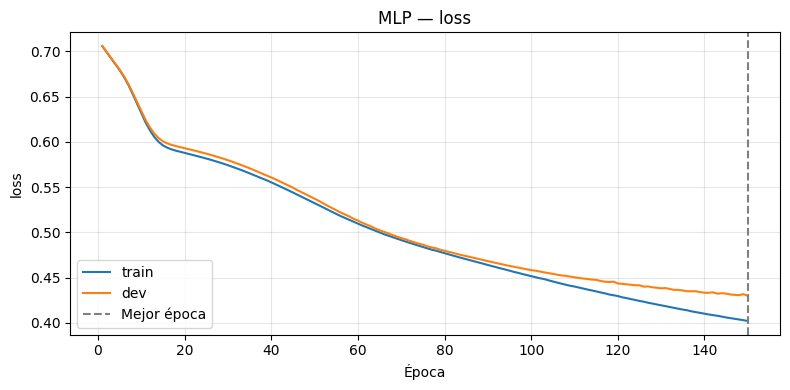

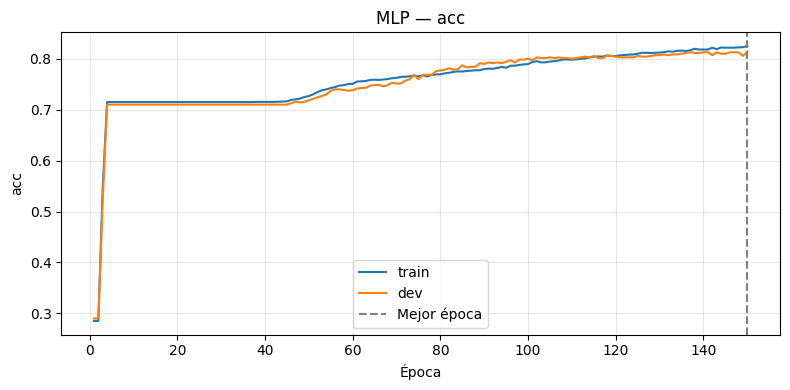

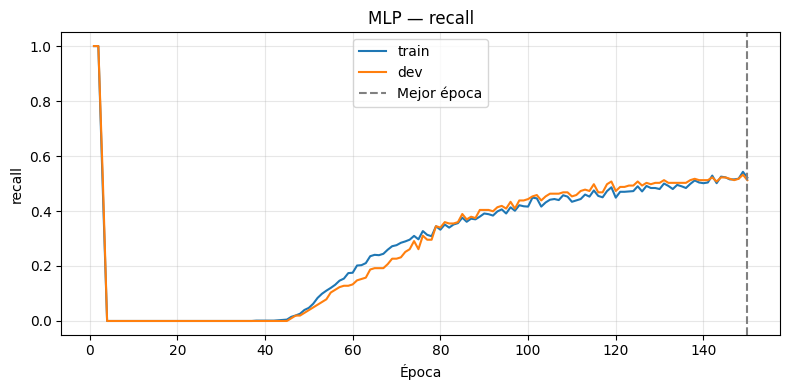

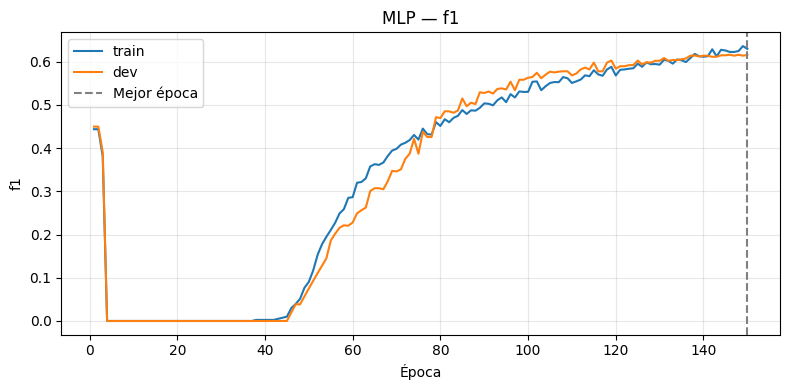

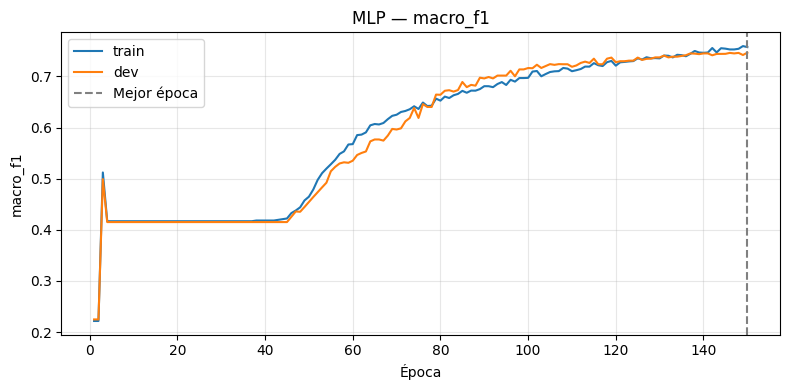

In [6]:
import copy
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

X_train_t = torch.tensor(X_train_pre, dtype=torch.float32)
y_train_t = torch.tensor(train_labels, dtype=torch.long)
X_dev_t = torch.tensor(X_dev_pre, dtype=torch.float32)
y_dev_t = torch.tensor(dev_labels, dtype=torch.long)
batch_size = 256
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(TensorDataset(X_dev_t, y_dev_t), batch_size=batch_size)
# CAMBIO: loader de evaluación de train separado del de entrenamiento.
# POR QUÉ: medir al final de la época, con pesos fijos y dropout apagado,
# de modo que train y dev se evalúen en las mismas condiciones.
train_eval_loader = DataLoader(train_dataset, batch_size=batch_size)

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 64), dropout=0.5, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], num_classes))

    def forward(self, x):
        return self.net(x)  # logits; CrossEntropyLoss no requiere softmax explícita

# CAMBIO: dimensión de entrada leída de los datos (ahora 300) y traslado al
# dispositivo ANTES del optimizador, que debe referenciar los parámetros definitivos.
input_dim = X_train_pre.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLPClassifier(input_dim=input_dim).to(device)
criterion = nn.CrossEntropyLoss()
# Se conservan estos hiperparámetros originales; no se afirma que sean óptimos.
# Primero ejecutar esta versión y, si se ajustan, decidir únicamente usando dev.
LEARNING_RATE_MLP = 5e-5
WEIGHT_DECAY_MLP = 1e-4
num_epochs = 150
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE_MLP,
                             weight_decay=WEIGHT_DECAY_MLP)

def evaluate_split(model, dataloader):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            total_loss += criterion(outputs, labels).item() * len(labels)
            all_preds.extend(outputs.argmax(dim=1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    pos_p, pos_r, pos_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", pos_label=1, zero_division=0)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, labels=[0, 1], average="macro", zero_division=0)
    # CAMBIO: distinguir F1 de clickbait de macro-F1 (promedio de F1 de ambas clases).
    # zero_division=0 define el resultado cuando todavía no se predice una clase.
    return {"loss": total_loss / len(dataloader.dataset),
            "acc": accuracy_score(all_labels, all_preds),
            "precision": pos_p, "recall": pos_r, "f1": pos_f1,
            "macro_precision": macro_p, "macro_recall": macro_r, "macro_f1": macro_f1,
            "targets": np.array(all_labels), "predictions": np.array(all_preds)}

# CAMBIO: baseline mayoritario para interpretar accuracy frente al desbalance.
# La clase mayoritaria se determina en TRAIN, no en dev ni test.
majority_class = np.bincount(train_labels, minlength=2).argmax()
baseline_preds = np.full(len(dev_labels), majority_class)
_, _, baseline_macro_f1, _ = precision_recall_fscore_support(
    dev_labels, baseline_preds, labels=[0, 1], average="macro", zero_division=0)
print(f"Baseline dev (siempre {CLICKBAIT_LABELS[majority_class]}): "
      f"accuracy={accuracy_score(dev_labels, baseline_preds):.4f}; macro-F1={baseline_macro_f1:.4f}")

# CAMBIO: test se elimina del bucle, history y curvas.
# POR QUÉ: reservarlo para la evaluación final de parte 4, evitando que sus
# resultados influyan en la selección o el ajuste de hiperparámetros.
metric_names = ["loss", "acc", "recall", "f1", "macro_f1"]
history = {"epoch": []}
for split in ["train", "dev"]:
    for metric in metric_names:
        history[f"{split}_{metric}"] = []
best_state, best_epoch = None, 0
best_dev_macro_f1 = -1.0

for epoch in range(1, num_epochs + 1):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()

    train_result = evaluate_split(model, train_eval_loader)
    dev_result = evaluate_split(model, dev_loader)
    history["epoch"].append(epoch)
    for split, result in [("train", train_result), ("dev", dev_result)]:
        for metric in metric_names:
            history[f"{split}_{metric}"].append(result[metric])

    # CAMBIO: seleccionar por macro-F1 en dev, antes se elegía por accuracy.
    # POR QUÉ: dar el mismo peso a las dos clases y alinearse con la parte 4.
    # En empates se conserva la primera época que consiguió ese valor.
    if dev_result["macro_f1"] > best_dev_macro_f1:
        best_dev_macro_f1 = dev_result["macro_f1"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
    if epoch % 10 == 0:
        print(f"Época {epoch:03d}/{num_epochs} | train loss={train_result['loss']:.4f} | "
              f"dev acc={dev_result['acc']:.4f} | dev recall(+)={dev_result['recall']:.4f} | "
              f"dev F1(+)={dev_result['f1']:.4f} | dev macro-F1={dev_result['macro_f1']:.4f}")

model.load_state_dict(best_state)
model.eval()
# Alias explícito para poder comparar con model_lstm en la parte 4.
model_mlp = model
history = {key: np.array(values) for key, values in history.items()}
print(f"Mejor época MLP: {best_epoch}; macro-F1 dev: {best_dev_macro_f1:.4f}")
print(model_mlp)
for metric in metric_names:
    plt.figure(figsize=(8, 4))
    for split in ["train", "dev"]:
        plt.plot(history["epoch"], history[f"{split}_{metric}"], label=split)
    plt.axvline(best_epoch, color="gray", linestyle="--", label="Mejor época")
    plt.xlabel("Época")
    plt.ylabel(metric)
    plt.title(f"MLP — {metric}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Describa las características de su mejor modelo, incluyendo arquitectura e hiperparámetros. Evalúelo sobre el corpus de **dev**, imprimiendo la métrica accuracy, y las métricas macro-precision, macro-recall y macro-F1, así como precision, recall y F1 de la clase positiva. Incluya también una matriz de confusión.

---



                 acc: 0.8143
     macro_precision: 0.7976
        macro_recall: 0.7250
            macro_f1: 0.7465
           precision: 0.7704
              recall: 0.5123
                  f1: 0.6154
precision, recall y f1 sin prefijo macro corresponden a Clickbait.


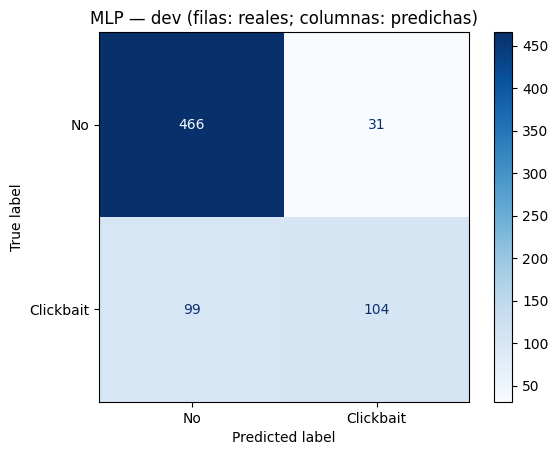

In [7]:
# CAMBIO: evaluar el checkpoint restaurado por macro-F1 usando la misma
# función que en entrenamiento; así no se duplican reglas de evaluación.
from sklearn.metrics import ConfusionMatrixDisplay
results_dev_mlp = evaluate_split(model_mlp, dev_loader)
for key in ["acc", "macro_precision", "macro_recall", "macro_f1", "precision", "recall", "f1"]:
    print(f"{key:>20}: {results_dev_mlp[key]:.4f}")
print("precision, recall y f1 sin prefijo macro corresponden a Clickbait.")
cm_dev = confusion_matrix(results_dev_mlp["targets"], results_dev_mlp["predictions"], labels=[0, 1])
ConfusionMatrixDisplay(cm_dev, display_labels=CLICKBAIT_LABELS).plot(cmap="Blues", values_format="d")
plt.title("MLP — dev (filas: reales; columnas: predichas)")
plt.grid(False)
plt.show()

**Descripción del modelo:**

Se implementó un clasificador binario MLP (Multi-Layer Perceptron) para detectar clickbait a partir del texto del titular.

**Preprocesamiento y representación:**
- Se convierte el texto a minúsculas, conservando tildes y ñ.
- Se mantienen las stop words, ya que palabras como “qué” o “cómo” pueden aportar información para detectar clickbait.
- Se utilizan embeddings preentrenados fastText de Wikipedia en español, de 300 dimensiones, sin entrenarlos ni modificarlos.
- Se conservan únicamente los vectores de palabras presentes en train. Las palabras fuera de ese vocabulario se ignoran al calcular el centroide.
- Cada titular se representa mediante el promedio de sus vectores conocidos. Si no tiene ninguno, se utiliza un vector cero.
- La cobertura de tokens fue de 94,88 % en train y 83,37 % en dev. No hubo titulares sin vectores conocidos.

**Arquitectura:**
- Entrada: centroide de 300 dimensiones.
- Dos capas ocultas de 256 y 64 unidades, respectivamente.
- Activación ReLU y dropout de 0,5 después de cada capa oculta.
- Salida: 2 logits, correspondientes a las clases No y Clickbait.
- No se aplica softmax explícitamente, ya que se utiliza CrossEntropyLoss.

**Entrenamiento:**
- Optimizador: Adam.
- Learning rate: 0,00005.
- Weight decay: 0,0001.
- Tamaño de batch: 256.
- Número de épocas: 150.
- Función de pérdida: CrossEntropyLoss, sin ponderación de clases.
- Semilla: 42.

**Selección y evaluación:**

Se conserva el modelo con mayor macro-F1 en dev, dando el mismo peso al F1 de ambas clases. El mejor checkpoint correspondió a la época 150.

Las métricas de train y dev se calculan al finalizar cada época, con los pesos fijos y el dropout desactivado. El conjunto de test se reserva para la evaluación final de la parte 4.

**Resultados en dev:**

| Métrica | Valor |
|---|---:|
| Accuracy | 0,8143 |
| Macro-precision | 0,7976 |
| Macro-recall | 0,7250 |
| Macro-F1 | 0,7465 |
| Precision de Clickbait | 0,7704 |
| Recall de Clickbait | 0,5123 |
| F1 de Clickbait | 0,6154 |

El baseline que predice siempre No obtiene una accuracy de 0,7100 y un macro-F1 de 0,4152. El MLP supera ambos valores y detecta 104 de los 203 titulares clickbait de dev. Sin embargo, deja 99 sin detectar, por lo que todavía existe margen de mejora en el recall de la clase positiva.

## Parte 2

Utilizando pytorch, construir un clasificador utilizando una arquitectura LSTM que clasifique los textos en clickbait o no clickbait.
Se deben utilizar **word embeddings** para representar cada palabra de los textos como entrada de la red.

**Sugerencias:**
* Puede utilizar los mismos word embeddings de la parte 1.
* Se recomienda usar como referencia el taller de LSTM, pero debe adaptar la arquitectura para que funcione como clasificador en lugar de etiquetado secuencial.
  * Para ello se recomienda tomar la capa oculta correspondiente a la última palabra que **no** es un token PAD (tener cuidado con el manejo de los batches).
  * Otra opción posible es tomar el promedio de las capas ocultas descartando las correspondientes a tokens PAD.
* Tener cuidado con el manejo de batches, siendo consistente con la flag de batch_first (en la definición de la capa LSTM de la red así como en la collate_fn del DataLoader).
* Usar el optimizador Adam en lugar de SGD.

Época 01 | train loss=0.5186 | dev loss=0.5396 | dev acc=0.7114 | dev macro-F1=0.4297
Época 02 | train loss=0.4491 | dev loss=0.4882 | dev acc=0.8186 | dev macro-F1=0.7528
Época 03 | train loss=0.4348 | dev loss=0.4549 | dev acc=0.8171 | dev macro-F1=0.7696
Época 04 | train loss=0.3654 | dev loss=0.4271 | dev acc=0.8257 | dev macro-F1=0.7658
Época 05 | train loss=0.3567 | dev loss=0.4311 | dev acc=0.8343 | dev macro-F1=0.7661
Época 06 | train loss=0.4025 | dev loss=0.4948 | dev acc=0.8171 | dev macro-F1=0.7231
Época 07 | train loss=0.3173 | dev loss=0.4362 | dev acc=0.8071 | dev macro-F1=0.7725
Época 08 | train loss=0.2810 | dev loss=0.4305 | dev acc=0.8371 | dev macro-F1=0.7730
Época 09 | train loss=0.2727 | dev loss=0.4450 | dev acc=0.8043 | dev macro-F1=0.7738
Época 10 | train loss=0.2809 | dev loss=0.5890 | dev acc=0.8300 | dev macro-F1=0.7540
Época 11 | train loss=0.1429 | dev loss=0.5572 | dev acc=0.8229 | dev macro-F1=0.7698
Época 12 | train loss=0.1264 | dev loss=0.5981 | dev a

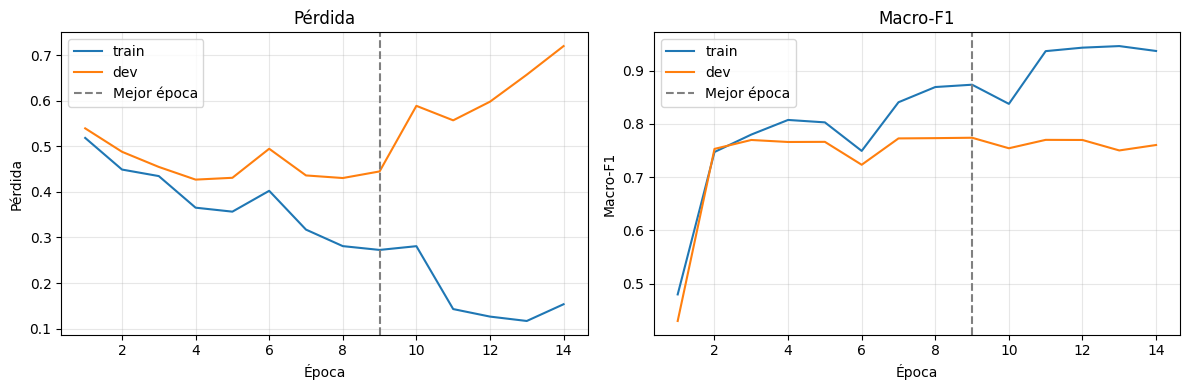

In [8]:
# Parte 2: datos secuenciales, modelo y entrenamiento.
# Ejecutar antes las celdas de preparación y la carga de wv de la parte 1.
import copy
import re
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

SEED_LSTM = 42
torch.manual_seed(SEED_LSTM)
np.random.seed(SEED_LSTM)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_LSTM)
device_lstm = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CAMBIO de compatibilidad con parte 1: reutilizar exactamente clean_text.
# POR QUÉ: comparar arquitecturas sin cambiar además tildes ni stop words.
# wv ahora contiene vectores fastText españoles de 300 dimensiones.
def tokenize_lstm(text):
    return clean_text(text)

train_tokens_lstm = [tokenize_lstm(t) for t in train_text]
dev_tokens_lstm = [tokenize_lstm(t) for t in dev_text]

# Vocabulario construido SOLO con train. PAD rellena; UNK sustituye OOV.
PAD_ID, UNK_ID = 0, 1
known_words = sorted({w for tokens in train_tokens_lstm for w in tokens if w in wv})
word_to_id_lstm = {w: i + 2 for i, w in enumerate(known_words)}
embedding_matrix_lstm = np.zeros((len(known_words) + 2, wv.vector_size), dtype=np.float32)
for word, idx in word_to_id_lstm.items():
    embedding_matrix_lstm[idx] = wv[word]
# UNK es un promedio fijo de vectores conocidos de train; no se entrena.
if known_words:
    embedding_matrix_lstm[UNK_ID] = embedding_matrix_lstm[2:].mean(axis=0)
else:
    raise ValueError("No hay palabras de train cubiertas por los embeddings.")

def encode_lstm(tokens):
    ids = [word_to_id_lstm.get(w, UNK_ID) for w in tokens]
    # pack_padded_sequence requiere al menos un elemento por secuencia.
    return torch.tensor(ids if ids else [UNK_ID], dtype=torch.long)

def make_lstm_dataset(token_lists, labels):
    return [(encode_lstm(tokens), int(label)) for tokens, label in zip(token_lists, labels)]

def collate_lstm(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=PAD_ID)
    return padded, lengths, torch.tensor(labels, dtype=torch.long)

BATCH_SIZE_LSTM = 32
train_dataset_lstm = make_lstm_dataset(train_tokens_lstm, train_labels)
dev_dataset_lstm = make_lstm_dataset(dev_tokens_lstm, dev_labels)
train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=BATCH_SIZE_LSTM,
                              shuffle=True, collate_fn=collate_lstm)
dev_loader_lstm = DataLoader(dev_dataset_lstm, batch_size=BATCH_SIZE_LSTM,
                            shuffle=False, collate_fn=collate_lstm)
# Loader sin mezcla para evaluar train en las mismas condiciones que dev.
train_eval_loader_lstm = DataLoader(train_dataset_lstm, batch_size=BATCH_SIZE_LSTM,
                                   shuffle=False, collate_fn=collate_lstm)

class LSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=True, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(input_size=embedding_matrix.shape[1],
                            hidden_size=hidden_dim, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, token_ids, lengths):
        # [batch, tiempo] -> [batch, tiempo, dimensión del embedding]
        embedded = self.embedding(token_ids)
        packed = pack_padded_sequence(embedded, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        # Al empaquetar, h_n[-1] corresponde al último token real de cada texto.
        # [batch, hidden_dim] -> [batch, 2]: una predicción por titular.
        return self.classifier(self.dropout(h_n[-1]))

HIDDEN_DIM_LSTM = 128
DROPOUT_LSTM = 0.3
LR_LSTM = 1e-3
WEIGHT_DECAY_LSTM = 1e-4
MAX_EPOCHS_LSTM = 30
PATIENCE_LSTM = 5
model_lstm = LSTMClassifier(embedding_matrix_lstm, HIDDEN_DIM_LSTM, DROPOUT_LSTM).to(device_lstm)
criterion_lstm = nn.CrossEntropyLoss()
optimizer_lstm = torch.optim.Adam(
    (p for p in model_lstm.parameters() if p.requires_grad),
    lr=LR_LSTM, weight_decay=WEIGHT_DECAY_LSTM)

def evaluate_lstm(model, loader):
    model.eval()
    total_loss, targets, predictions = 0.0, [], []
    with torch.no_grad():
        for ids, lengths, labels in loader:
            ids, labels = ids.to(device_lstm), labels.to(device_lstm)
            logits = model(ids, lengths)
            total_loss += criterion_lstm(logits, labels).item() * len(labels)
            targets.extend(labels.cpu().tolist())
            predictions.extend(logits.argmax(dim=1).cpu().tolist())
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        targets, predictions, labels=[0, 1], average="macro", zero_division=0)
    pos_p, pos_r, pos_f1, _ = precision_recall_fscore_support(
        targets, predictions, average="binary", pos_label=1, zero_division=0)
    return {"loss": total_loss / len(loader.dataset),
            "accuracy": accuracy_score(targets, predictions),
            "macro_precision": macro_p, "macro_recall": macro_r, "macro_f1": macro_f1,
            "positive_precision": pos_p, "positive_recall": pos_r, "positive_f1": pos_f1,
            "targets": np.array(targets), "predictions": np.array(predictions)}

history_lstm = []
best_state_lstm, best_epoch_lstm = None, 0
best_macro_f1_lstm = -1.0
stale_epochs_lstm = 0
for epoch in range(1, MAX_EPOCHS_LSTM + 1):
    model_lstm.train()
    for ids, lengths, labels in train_loader_lstm:
        ids, labels = ids.to(device_lstm), labels.to(device_lstm)
        optimizer_lstm.zero_grad()
        logits = model_lstm(ids, lengths)
        loss = criterion_lstm(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)
        optimizer_lstm.step()

    train_result = evaluate_lstm(model_lstm, train_eval_loader_lstm)
    dev_result = evaluate_lstm(model_lstm, dev_loader_lstm)
    history_lstm.append({"epoch": epoch,
                        "train_loss": train_result["loss"], "dev_loss": dev_result["loss"],
                        "train_macro_f1": train_result["macro_f1"],
                        "dev_macro_f1": dev_result["macro_f1"]})
    print(f"Época {epoch:02d} | train loss={train_result['loss']:.4f} | "
          f"dev loss={dev_result['loss']:.4f} | dev acc={dev_result['accuracy']:.4f} | "
          f"dev macro-F1={dev_result['macro_f1']:.4f}")
    if dev_result["macro_f1"] > best_macro_f1_lstm:
        best_macro_f1_lstm = dev_result["macro_f1"]
        best_epoch_lstm = epoch
        best_state_lstm = copy.deepcopy(model_lstm.state_dict())
        stale_epochs_lstm = 0
    else:
        stale_epochs_lstm += 1
        if stale_epochs_lstm >= PATIENCE_LSTM:
            print("Parada temprana: 5 épocas sin mejorar macro-F1 en dev.")
            break

model_lstm.load_state_dict(best_state_lstm)
print(f"Mejor época: {best_epoch_lstm}; macro-F1 dev: {best_macro_f1_lstm:.4f}")
print(model_lstm)
print("Parámetros entrenables:", sum(p.numel() for p in model_lstm.parameters() if p.requires_grad))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(axes, ["loss", "macro_f1"], ["Pérdida", "Macro-F1"]):
    for split in ["train", "dev"]:
        ax.plot([r["epoch"] for r in history_lstm],
                [r[f"{split}_{metric}"] for r in history_lstm], label=split)
    ax.axvline(best_epoch_lstm, color="gray", linestyle="--", label="Mejor época")
    ax.set(xlabel="Época", ylabel=title, title=title)
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


Describa las características de su mejor modelo, incluyendo arquitectura e hiperparámetros. Evalúelo sobre el corpus de **dev**, imprimiendo la métrica accuracy, y las métricas macro-precision, macro-recall y macro-F1, así como precision, recall y F1 de la clase positiva. Incluya también una matriz de confusión.


            accuracy: 0.8043
     macro_precision: 0.7644
        macro_recall: 0.7893
            macro_f1: 0.7738
  positive_precision: 0.6375
     positive_recall: 0.7537
         positive_f1: 0.6907


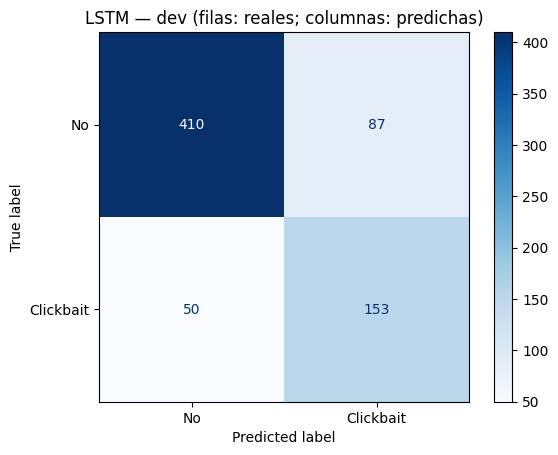

In [9]:
# Métricas solicitadas: evaluar el checkpoint restaurado, exclusivamente en dev.
results_dev_lstm = evaluate_lstm(model_lstm, dev_loader_lstm)
for key in ["accuracy", "macro_precision", "macro_recall", "macro_f1",
            "positive_precision", "positive_recall", "positive_f1"]:
    print(f"{key:>20}: {results_dev_lstm[key]:.4f}")
cm_dev_lstm = confusion_matrix(results_dev_lstm["targets"],
                               results_dev_lstm["predictions"], labels=[0, 1])
ConfusionMatrixDisplay(cm_dev_lstm, display_labels=CLICKBAIT_LABELS).plot(
    cmap="Blues", values_format="d")
plt.title("LSTM — dev (filas: reales; columnas: predichas)")
plt.grid(False)
plt.show()


**Descripción del modelo:**

Se implementó un clasificador binario basado en una red LSTM para detectar clickbait a partir del texto del titular. A diferencia del MLP, que recibe un promedio de embeddings, la LSTM procesa una secuencia de vectores y tiene en cuenta el orden de las palabras.

**Preprocesamiento y representación:**
- Se utiliza el mismo preprocesamiento que en la parte 1: minúsculas, conservación de tildes y ñ, y mantenimiento de stop words.
- Cada palabra se representa mediante un embedding preentrenado fastText de Wikipedia en español, de 300 dimensiones.
- Los embeddings permanecen congelados durante el entrenamiento.
- El vocabulario se construye únicamente con palabras de train que tienen un vector preentrenado.
- Las palabras fuera del vocabulario se sustituyen por UNK, cuyo vector es el promedio fijo de los embeddings conocidos de train.
- Se utiliza PAD para igualar las longitudes de los titulares dentro de cada batch. Los textos sin tokens se representan con un UNK.

**Arquitectura:**
- Capa de embeddings de 300 dimensiones.
- Una capa LSTM unidireccional con 128 unidades ocultas.
- Dropout de 0,3 aplicado al estado oculto final.
- Capa lineal de 128 entradas y 2 salidas, correspondientes a No y Clickbait.

Se utiliza pack_padded_sequence para excluir el padding del procesamiento recurrente. De esta forma, el estado oculto final corresponde al último token real de cada titular. Ese estado se utiliza para generar una única predicción por texto, en lugar de una predicción por palabra.

La configuración batch_first=True se mantiene tanto en la preparación de los batches como en la LSTM. La salida contiene logits y no se aplica softmax explícitamente antes de CrossEntropyLoss.

**Entrenamiento:**
- Optimizador: Adam.
- Learning rate: 0,001.
- Weight decay: 0,0001.
- Tamaño de batch: 32.
- Máximo de épocas: 30.
- Función de pérdida: CrossEntropyLoss, sin ponderación de clases.
- Recorte de la norma del gradiente a un máximo de 1,0 para limitar actualizaciones excesivas.
- Semilla: 42.

**Selección del mejor modelo:**

Se conserva el checkpoint con mayor macro-F1 en dev. Se aplica early stopping con una paciencia de 5 épocas sin mejora.

El entrenamiento se detuvo en la época 14 y se restauraron los pesos de la época 9, que obtuvo el mejor macro-F1 en dev. Las métricas de train y dev se calculan con dropout desactivado. Test se reserva para la evaluación final de la parte 4.

**Resultados e interpretación:**

El modelo seleccionado obtuvo en dev:
- Accuracy: 0,8043.
- Macro-F1: 0,7738.

La LSTM superó el macro-F1 del MLP (0,7465), aunque obtuvo una accuracy ligeramente inferior. Por lo tanto, resulta el mejor de los dos modelos según el criterio de comparación establecido en la consigna.

Durante las últimas épocas disminuyó la pérdida de train mientras aumentó la de dev, lo que indica sobreajuste. La selección del checkpoint y la parada temprana permitieron conservar un modelo anterior al final del entrenamiento.

La evaluación detallada con macro-precision, macro-recall, métricas de la clase positiva y matriz de confusión se completa en la celda de evaluación de dev.

## Parte 3 (opcional):
Elija uno de los clasificadores anteriores y realice una búsqueda automatizada de hiperparámetros del modelo. Por ejemplo, puede utilizar una búsqueda en grilla completa o una búsqueda aleatoria, eligiendo diferente cantidad de capas, número unidades por capa, funciones de activación, y valores de learning rate. Intente encontrar el mejor clasificador posible, comparándolos sobre el corpus de **dev**.

In [10]:
import itertools
import copy
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Reutilizamos los centroides, datasets y evaluate_split de la parte 1.
# Los embeddings y el preprocesamiento son iguales en todos los experimentos:
# así comparamos los hiperparámetros del clasificador.

class MLPBusqueda(nn.Module):
    def __init__(self, input_dim, hidden_dims, activation, dropout=0.3):
        super().__init__()

        activaciones = {
            "ReLU": nn.ReLU,
            "Tanh": nn.Tanh,
        }

        capas = []
        dimension_anterior = input_dim

        for dimension_oculta in hidden_dims:
            capas.extend([
                nn.Linear(dimension_anterior, dimension_oculta),
                activaciones[activation](),
                nn.Dropout(dropout),
            ])
            dimension_anterior = dimension_oculta

        # Dos logits: No y Clickbait.
        capas.append(nn.Linear(dimension_anterior, 2))
        self.net = nn.Sequential(*capas)

    def forward(self, x):
        return self.net(x)


# 3 arquitecturas × 2 activaciones × 3 learning rates = 18 modelos.
grilla = {
    "hidden_dims": [(64,), (128,), (128, 64)],
    "activation": ["ReLU", "Tanh"],
    "lr": [1e-4, 5e-4, 1e-3],
}

# Parámetros que mantenemos fijos.
SEMILLA = 42
BATCH_SIZE = 256
DROPOUT = 0.3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 150
PATIENCE = 12

configuraciones = list(itertools.product(
    grilla["hidden_dims"],
    grilla["activation"],
    grilla["lr"],
))

resultados_busqueda = []
mejor_macro_f1 = -1.0
mejor_configuracion = None
mejor_estado = None

for numero, (hidden_dims, activation, lr) in enumerate(configuraciones, 1):

    # Reiniciamos semillas y modelo para cada configuración.
    # Cada experimento se entrena desde cero.
    torch.manual_seed(SEMILLA)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEMILLA)

    # Generador independiente: mismo orden de batches entre experimentos.
    generador = torch.Generator().manual_seed(SEMILLA)
    loader_busqueda = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generador,
    )

    candidato = MLPBusqueda(
        input_dim=X_train_pre.shape[1],
        hidden_dims=hidden_dims,
        activation=activation,
        dropout=DROPOUT,
    ).to(device)

    optimizador = torch.optim.Adam(
        candidato.parameters(),
        lr=lr,
        weight_decay=WEIGHT_DECAY,
    )

    mejor_f1_config = -1.0
    mejor_estado_config = None
    mejores_metricas_config = None
    mejor_epoca_config = 0
    epocas_sin_mejora = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        candidato.train()

        for inputs, labels in loader_busqueda:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizador.zero_grad()
            logits = candidato(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizador.step()

        # Exclusivamente dev para seleccionar el checkpoint y detenernos.
        metricas_dev = evaluate_split(candidato, dev_loader)

        if metricas_dev["macro_f1"] > mejor_f1_config:
            mejor_f1_config = metricas_dev["macro_f1"]
            mejor_epoca_config = epoch

            # Copia independiente en CPU para conservar los pesos.
            mejor_estado_config = {
                nombre: tensor.detach().cpu().clone()
                for nombre, tensor in candidato.state_dict().items()
            }

            mejores_metricas_config = {
                clave: metricas_dev[clave]
                for clave in ["acc", "macro_f1", "precision", "recall", "f1"]
            }
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1

        if epocas_sin_mejora >= PATIENCE:
            break

    resultados_busqueda.append({
        "capas_ocultas": hidden_dims,
        "activacion": activation,
        "lr": lr,
        "mejor_epoca": mejor_epoca_config,
        "epocas_ejecutadas": epoch,
        "accuracy_dev": mejores_metricas_config["acc"],
        "macro_f1_dev": mejor_f1_config,
        "precision_clickbait": mejores_metricas_config["precision"],
        "recall_clickbait": mejores_metricas_config["recall"],
        "f1_clickbait": mejores_metricas_config["f1"],
    })

    print(
        f"[{numero:02d}/{len(configuraciones)}] "
        f"Capas={hidden_dims} | {activation} | lr={lr} | "
        f"Mejor época={mejor_epoca_config} | "
        f"Macro-F1 dev={mejor_f1_config:.4f}"
    )

    # Elegimos el mejor checkpoint entre todas las configuraciones.
    # En empates, conservamos la primera configuración.
    if mejor_f1_config > mejor_macro_f1:
        mejor_macro_f1 = mejor_f1_config
        mejor_estado = mejor_estado_config
        mejor_configuracion = {
            "hidden_dims": hidden_dims,
            "activation": activation,
            "lr": lr,
            "dropout": DROPOUT,
            "weight_decay": WEIGHT_DECAY,
            "batch_size": BATCH_SIZE,
            "best_epoch": mejor_epoca_config,
        }


# Tabla ordenada de mayor a menor macro-F1.
tabla_busqueda = (
    pd.DataFrame(resultados_busqueda)
    .sort_values("macro_f1_dev", ascending=False, kind="stable")
    .reset_index(drop=True)
)
display(tabla_busqueda)

# Reconstruimos el mejor modelo y restauramos sus pesos.
# Nombre diferente para conservar también los modelos de las partes 1 y 2.
model_grid = MLPBusqueda(
    input_dim=X_train_pre.shape[1],
    hidden_dims=mejor_configuracion["hidden_dims"],
    activation=mejor_configuracion["activation"],
    dropout=mejor_configuracion["dropout"],
).to(device)

model_grid.load_state_dict(mejor_estado)
model_grid.eval()

print("\nMejor configuración:")
print(mejor_configuracion)
print(f"Macro-F1 en dev: {mejor_macro_f1:.4f}")
print(model_grid)


[01/18] Capas=(64,) | ReLU | lr=0.0001 | Mejor época=4 | Macro-F1 dev=0.4152
[02/18] Capas=(64,) | ReLU | lr=0.0005 | Mejor época=105 | Macro-F1 dev=0.7683
[03/18] Capas=(64,) | ReLU | lr=0.001 | Mejor época=88 | Macro-F1 dev=0.7681
[04/18] Capas=(64,) | Tanh | lr=0.0001 | Mejor época=2 | Macro-F1 dev=0.4152
[05/18] Capas=(64,) | Tanh | lr=0.0005 | Mejor época=76 | Macro-F1 dev=0.7547
[06/18] Capas=(64,) | Tanh | lr=0.001 | Mejor época=23 | Macro-F1 dev=0.7462
[07/18] Capas=(128,) | ReLU | lr=0.0001 | Mejor época=1 | Macro-F1 dev=0.4152
[08/18] Capas=(128,) | ReLU | lr=0.0005 | Mejor época=34 | Macro-F1 dev=0.7383
[09/18] Capas=(128,) | ReLU | lr=0.001 | Mejor época=23 | Macro-F1 dev=0.7469
[10/18] Capas=(128,) | Tanh | lr=0.0001 | Mejor época=1 | Macro-F1 dev=0.4152
[11/18] Capas=(128,) | Tanh | lr=0.0005 | Mejor época=74 | Macro-F1 dev=0.7586
[12/18] Capas=(128,) | Tanh | lr=0.001 | Mejor época=83 | Macro-F1 dev=0.7600
[13/18] Capas=(128, 64) | ReLU | lr=0.0001 | Mejor época=1 | Macr

,capas_ocultas,activacion,lr,mejor_epoca,epocas_ejecutadas,accuracy_dev,macro_f1_dev,precision_clickbait,recall_clickbait,f1_clickbait
0,"(128, 64)",ReLU,0.0010,46,58,0.820000,0.773192,0.715084,0.630542,0.670157
1,"(128, 64)",ReLU,0.0005,54,66,0.817143,0.770341,0.707182,0.630542,0.666667
2,"(64,)",ReLU,0.0005,105,117,0.812857,0.768289,0.689474,0.645320,0.666667
3,"(64,)",ReLU,0.0010,88,100,0.817143,0.768066,0.714286,0.615764,0.661376
4,"(128, 64)",Tanh,0.0010,27,39,0.808571,0.760350,0.688525,0.620690,0.652850
5,"(128,)",Tanh,0.0010,83,95,0.811429,0.760015,0.705202,0.600985,0.648936
6,"(128, 64)",Tanh,0.0005,45,57,0.810000,0.759406,0.698864,0.605911,0.649077
7,"(128,)",Tanh,0.0005,74,86,0.810000,0.758603,0.701149,0.600985,0.647215
8,"(64,)",Tanh,0.0005,76,88,0.808571,0.754717,0.704142,0.586207,0.639785
9,"(128,)",ReLU,0.0010,23,35,0.787143,0.746942,0.623853,0.669951,0.646081



Mejor configuración:
{'hidden_dims': (128, 64), 'activation': 'ReLU', 'lr': 0.001, 'dropout': 0.3, 'weight_decay': 0.0001, 'batch_size': 256, 'best_epoch': 46}
Macro-F1 en dev: 0.7732
MLPBusqueda(
  (net): Sequential(
    (0): Linear(in_features=300, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


Describa las características de su mejor modelo, incluyendo arquitectura e hiperparámetros. Evalúelo sobre el corpus de **dev**, imprimiendo la métrica accuracy, y las métricas macro-precision, macro-recall y macro-F1, así como precision, recall y F1 de la clase positiva. Incluya también una matriz de confusión.

Evaluación del mejor MLP de la búsqueda — DEV
                 acc: 0.8200
     macro_precision: 0.7856
        macro_recall: 0.7640
            macro_f1: 0.7732
           precision: 0.7151
              recall: 0.6305
                  f1: 0.6702
Las métricas sin prefijo macro corresponden a Clickbait.


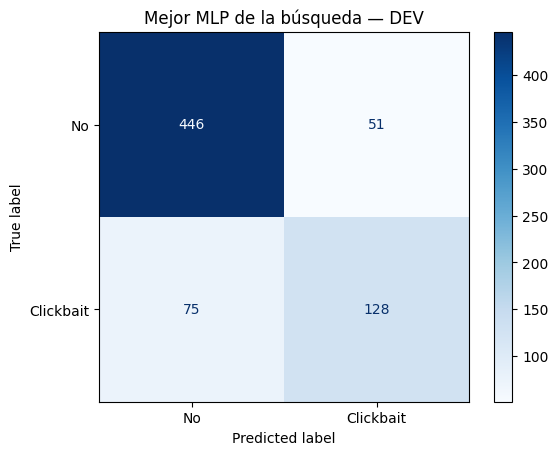

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results_dev_grid = evaluate_split(model_grid, dev_loader)

print("Evaluación del mejor MLP de la búsqueda — DEV")
for clave in [
    "acc", "macro_precision", "macro_recall", "macro_f1",
    "precision", "recall", "f1",
]:
    print(f"{clave:>20}: {results_dev_grid[clave]:.4f}")

print("Las métricas sin prefijo macro corresponden a Clickbait.")

cm_grid = confusion_matrix(
    results_dev_grid["targets"],
    results_dev_grid["predictions"],
    labels=[0, 1],
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_grid,
    display_labels=CLICKBAIT_LABELS,
).plot(cmap="Blues", values_format="d")

plt.title("Mejor MLP de la búsqueda — DEV")
plt.grid(False)
plt.show()

**Búsqueda de hiperparámetros:**

Se realizó una búsqueda en grilla sobre el clasificador MLP, manteniendo los centroides de embeddings fastText en español y el preprocesamiento de la parte 1.

Se evaluaron 18 combinaciones:
- Capas ocultas: (64), (128) y (128, 64).
- Funciones de activación: ReLU y Tanh.
- Learning rates: 0,0001; 0,0005 y 0,001.

Cada configuración se entrenó desde cero, utilizando la semilla 42 y el mismo orden de batches. Se seleccionó el checkpoint con mayor macro-F1 en dev, sin utilizar test durante la búsqueda.

**Arquitectura del mejor modelo encontrado:**
- Entrada: centroide de embeddings de 300 dimensiones.
- Primera capa oculta: 128 unidades, activación ReLU y dropout de 0,3.
- Segunda capa oculta: 64 unidades, activación ReLU y dropout de 0,3.
- Salida: 2 logits, correspondientes a No y Clickbait.
- Los embeddings preentrenados permanecen fijos.

**Configuración de entrenamiento:**
- Optimizador: Adam.
- Learning rate: 0,001.
- Weight decay: 0,0001.
- Tamaño de batch: 256.
- Función de pérdida: CrossEntropyLoss, sin ponderación de clases.
- Máximo de épocas: 150.
- Early stopping: paciencia de 12 épocas sin mejora del macro-F1 en dev.

El mejor checkpoint se obtuvo en la época 46. El entrenamiento de esta configuración finalizó en la época 58 y se restauraron los pesos de la época seleccionada.

**Resultados en dev:**

| Métrica | Valor |
|---|---:|
| Accuracy | 0,8200 |
| Macro-precision | 0,7856 |
| Macro-recall | 0,7640 |
| Macro-F1 | 0,7732 |
| Precision de Clickbait | 0,7151 |
| Recall de Clickbait | 0,6305 |
| F1 de Clickbait | 0,6702 |

**Análisis:**

La búsqueda mejoró el macro-F1 del MLP de la parte 1, pasando de 0,7465 a 0,7732. El recall de Clickbait aumentó de 0,5123 a 0,6305, permitiendo detectar 128 de los 203 titulares positivos de dev, frente a los 104 detectados anteriormente. Esta mejora estuvo acompañada de una disminución de la precision de la clase positiva.

El resultado quedó muy próximo al macro-F1 de la LSTM (0,7738). Según el criterio establecido, la LSTM mantiene el mejor resultado observado en dev, aunque la diferencia es demasiado pequeña para afirmar una superioridad general de esa arquitectura.

**Limitación de la búsqueda:**

Todas las configuraciones con learning rate 0,0001 se detuvieron tempranamente y sus checkpoints seleccionados predijeron únicamente la clase mayoritaria. El macro-F1 puede permanecer constante mientras la pérdida continúa disminuyendo, por lo que una paciencia de 12 épocas puede resultar insuficiente para estas configuraciones. En consecuencia, estos resultados no permiten concluir que ese learning rate sea inadecuado; sería necesario evaluarlo con un período mínimo de entrenamiento o mayor paciencia.

## Parte 4:

Elija el mejor clasificador de todos los construidos en las partes anteriores, comparándolos utilizando la medida macro-F1, y evalúelo sobre el corpus de **test**, imprimiendo la métrica accuracy, y las métricas macro-precision, macro-recall y macro-F1, así como precision, recall y F1 de la clase positiva.

In [12]:
# Elegimos la LSTM por su mayor macro-F1 en DEV.
# TEST se utiliza únicamente para evaluar el modelo ya seleccionado.
# Ejecutar previamente la parte 2 para disponer del modelo y sus funciones.

# Restauramos explícitamente el mejor checkpoint de la parte 2.
model_lstm.load_state_dict(best_state_lstm)
model_lstm.eval()

# Aplicamos exactamente el mismo preprocesamiento y vocabulario.
# Las palabras nuevas se convierten en UNK mediante encode_lstm.
test_tokens_lstm = [tokenize_lstm(text) for text in test_text]
test_dataset_lstm = make_lstm_dataset(test_tokens_lstm, test_labels)

test_loader_lstm = DataLoader(
    test_dataset_lstm,
    batch_size=BATCH_SIZE_LSTM,
    shuffle=False,
    collate_fn=collate_lstm,
)

# evaluate_lstm utiliza model.eval() y torch.no_grad().
results_test_lstm = evaluate_lstm(model_lstm, test_loader_lstm)

print("Modelo seleccionado: LSTM")
print(f"Checkpoint: época {best_epoch_lstm}")
print(f"Macro-F1 en dev: {best_macro_f1_lstm:.4f}")
print("\nEvaluación final en TEST")

metricas = [
    ("Accuracy", "accuracy"),
    ("Macro-precision", "macro_precision"),
    ("Macro-recall", "macro_recall"),
    ("Macro-F1", "macro_f1"),
    ("Precision de Clickbait", "positive_precision"),
    ("Recall de Clickbait", "positive_recall"),
    ("F1 de Clickbait", "positive_f1"),
]

for nombre, clave in metricas:
    print(f"{nombre:>23}: {results_test_lstm[clave]:.4f}")

Modelo seleccionado: LSTM
Checkpoint: época 9
Macro-F1 en dev: 0.7738

Evaluación final en TEST
               Accuracy: 0.7800
        Macro-precision: 0.7154
           Macro-recall: 0.7610
               Macro-F1: 0.7289
 Precision de Clickbait: 0.5284
    Recall de Clickbait: 0.7246
        F1 de Clickbait: 0.6111


Despliegue la matriz de confusión sobre el corpus de **test** para el mejor clasificador construido en las partes anteriores.

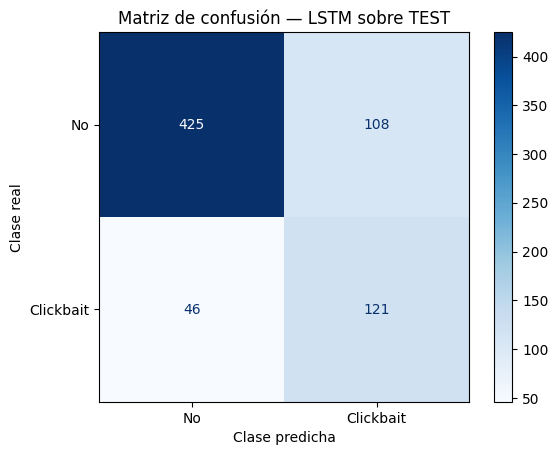

Verdaderos negativos — No correctamente clasificados: 425
Falsos positivos — No clasificados como Clickbait: 108
Falsos negativos — Clickbait clasificados como No: 46
Verdaderos positivos — Clickbait correctamente detectados: 121


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_test = confusion_matrix(
    results_test_lstm["targets"],
    results_test_lstm["predictions"],
    labels=[0, 1],
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=CLICKBAIT_LABELS,
).plot(cmap="Blues", values_format="d")

plt.title("Matriz de confusión — LSTM sobre TEST")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.grid(False)
plt.show()

# Clickbait es la clase positiva.
tn, fp, fn, tp = cm_test.ravel()

print(f"Verdaderos negativos — No correctamente clasificados: {tn}")
print(f"Falsos positivos — No clasificados como Clickbait: {fp}")
print(f"Falsos negativos — Clickbait clasificados como No: {fn}")
print(f"Verdaderos positivos — Clickbait correctamente detectados: {tp}")

Analice los resultados, y responda, al menos, las siguientes preguntas:

1.   ¿Cuál fue la arquitectura que funcionó mejor? Describa brevemente sus características.
2.   ¿Cuál es la forma del modelo? Indique cantidad de capas, unidades, funciones de activación, etc. Puede usar el método print() sobre el modelo para imprimir la forma del modelo.
3.   ¿Cuáles fueron las mayores dificultades encontradas en el desarrollo del laboratorio? Describa las dificultades encontradas así como la forma en que fueron remediadas.

### 1. ¿Cuál fue la arquitectura que funcionó mejor?

La arquitectura que obtuvo el mayor macro-F1 en dev fue la LSTM, con un valor de 0,7738. El MLP inicial obtuvo 0,7465 y el mejor MLP de la búsqueda de hiperparámetros alcanzó 0,7732.

La LSTM procesa los embeddings de las palabras en orden y utiliza el estado oculto correspondiente al último token real para clasificar el titular completo. A diferencia del MLP, conserva información sobre la secuencia, que se pierde al promediar los embeddings.

Se seleccionó la LSTM para la evaluación final en test siguiendo el criterio de macro-F1 establecido en la consigna. Sin embargo, la diferencia con el MLP optimizado es muy pequeña y no permite afirmar una superioridad general de la arquitectura LSTM. Además, el MLP optimizado obtuvo mayor accuracy en dev: 0,8200 frente a 0,8043.

En la evaluación final sobre test, la LSTM obtuvo una accuracy de 0,7800, macro-precision de 0,7154, macro-recall de 0,7610 y macro-F1 de 0,7289. El macro-F1 disminuyó respecto a dev (0,7738), con una diferencia de 0,0449, es decir, 4,49 puntos porcentuales. Esto muestra un rendimiento inferior sobre el conjunto reservado para la evaluación final, aunque esta diferencia por sí sola no demuestra sobreajuste. Para la clase Clickbait, obtuvo precision de 0,5284, recall de 0,7246 y F1 de 0,6111: detectó aproximadamente el 72,46 % de los clickbaits reales, pero solo el 52,84 % de los titulares que marcó como clickbait efectivamente lo eran. Por lo tanto, una limitación relevante es la cantidad de falsos positivos.

### 2. ¿Cuál es la forma del modelo?

El modelo seleccionado tiene los siguientes componentes:

- **Capa de embeddings:** 12.219 entradas de 300 dimensiones, incluyendo PAD y UNK. Se utilizan vectores preentrenados fastText en español, que permanecen congelados.
- **Capa LSTM:** una capa unidireccional con entradas de 300 dimensiones y 128 unidades ocultas. Internamente utiliza funciones sigmoid para las compuertas y tanh para el cálculo y transformación de los estados.
- **Dropout:** probabilidad de 0,3, aplicado al estado oculto final durante el entrenamiento.
- **Capa lineal de salida:** transforma el vector de 128 componentes en 2 logits, correspondientes a No y Clickbait.

No se aplica softmax explícitamente antes de CrossEntropyLoss. Para obtener la clase predicha se selecciona el logit de mayor valor.

El modelo cuenta con 220.418 parámetros entrenables, correspondientes a la LSTM y a la capa lineal. Los embeddings no se actualizan.

Se entrenó con Adam, learning rate de 0,001, weight decay de 0,0001 y batches de 32 ejemplos. Se utilizó recorte de la norma del gradiente a 1,0 y early stopping con paciencia de 5 épocas. El entrenamiento finalizó en la época 14 y se restauró el checkpoint de la época 9, que obtuvo el mejor macro-F1 en dev.

### 3. ¿Cuáles fueron las mayores dificultades y cómo se abordaron?

**Representación de los textos e idioma de los embeddings.**

La primera implementación utilizaba embeddings GloVe provenientes de un corpus en inglés para representar titulares en español. Se sustituyeron por vectores fastText en español. También se conservaron tildes, ñ y stop words, que pueden aportar información para distinguir titulares clickbait. El resultado del MLP mejoró, aunque no se puede atribuir toda la mejora a un único cambio porque se modificaron varios aspectos simultáneamente.

**Desbalance de clases y elección de la métrica.**

La clase No es mayoritaria. Un clasificador que predice siempre esa clase alcanza una accuracy de 0,71 en dev, pero no detecta ningún clickbait. Por eso, accuracy por sí sola podía dar una impresión engañosa del desempeño.

Se incorporó este baseline y se seleccionaron los modelos por macro-F1, que da el mismo peso al F1 de ambas clases. También se analizaron precision, recall y F1 de Clickbait.

**Manejo de titulares de distinta longitud.**

Para formar batches fue necesario rellenar las secuencias con PAD. Tomar directamente el último paso de un batch rellenado podía utilizar un estado correspondiente al padding.

Se resolvió mediante pack_padded_sequence y las longitudes reales de los textos. Así, el estado final de la LSTM corresponde al último token válido de cada titular. Se mantuvo batch_first=True de forma consistente.

**Palabras desconocidas.**

Al construir el vocabulario únicamente con train, aparecen palabras de dev y test que no están representadas. En el MLP se ignoran al calcular el centroide; en la LSTM se sustituyen por UNK, utilizando un vector fijo. No se incorporan nuevas palabras al vocabulario durante la evaluación.

**Sobreajuste y selección del checkpoint.**

En la LSTM, durante las últimas épocas disminuyó la pérdida de train mientras aumentaba la de dev, indicando sobreajuste. Se utilizaron dropout, weight decay y early stopping, conservando los pesos del checkpoint con mayor macro-F1 en dev.

Además, se reservó test para la evaluación final y se calcularon las métricas de train y dev con dropout desactivado, para comparar ambos conjuntos en las mismas condiciones.

**Parada prematura en la búsqueda de hiperparámetros.**

Las configuraciones del MLP con learning rate de 0,0001 se detuvieron mientras sus checkpoints seleccionados todavía predecían únicamente la clase mayoritaria. El macro-F1 puede mantenerse constante aunque la pérdida esté disminuyendo.

Esta limitación no quedó resuelta en la búsqueda realizada. Como mejora, se podría establecer una cantidad mínima de épocas antes de activar early stopping o aumentar la paciencia, para dar más tiempo a las configuraciones que aprenden lentamente.